ANALISIS REGRESI LINIER SEDERHANA: KINERJA SISWA
Dataframe Regresi (5 baris pertama):
   Study Hours (X)  Exam Scores (Y)
0              1.5               60
1              2.0               65
2              2.5               73
3              3.0               75
4              2.0               62
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Study Hours (X)  50 non-null     float64
 1   Exam Scores (Y)  50 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 928.0 bytes

Informasi Dataframe Regresi:
None

--- Preprocessing Data Regresi ---
Nama kolom setelah diubah: ['Jam_Belajar', 'Nilai_Ujian']
Jumlah nilai hilang per kolom:
Jam_Belajar    0
Nilai_Ujian    0
dtype: int64
Ukuran data latih: (40, 1), Ukuran data uji: (10, 1)

Persamaan Regresi (Y = a + bX):
Intercept (a): 40.13
Slope/Koefisien (b): 12.08
Model: Nilai_Uji

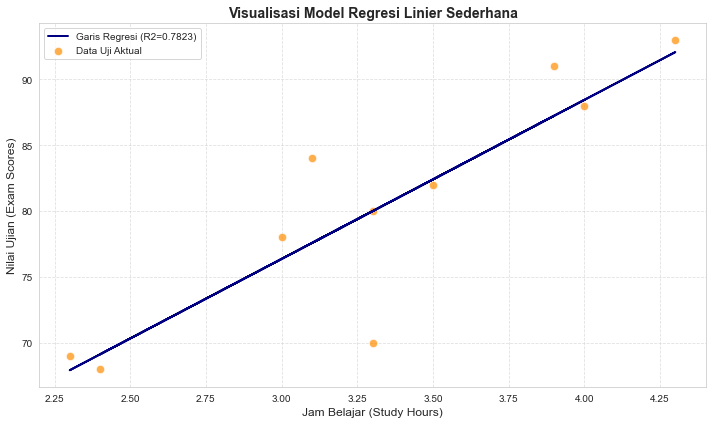


ANALISIS KLASIFIKASI NAIVE BAYES: PREDIKSI DIABETES
Dataframe Klasifikasi (5 baris pertama):
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               -----

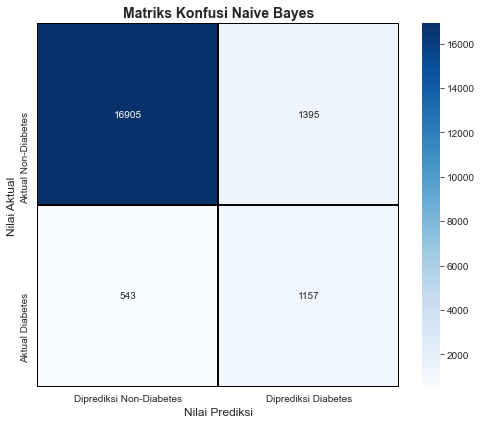


--- Contoh Pengujian Model (Klasifikasi) ---
Prediksi untuk data baru: Diabetes
Probabilitas Non-Diabetes: 0.0000, Probabilitas Diabetes: 1.0000

Kode selesai. Hasil visualisasi (regresi_model_visualisasi.png dan klasifikasi_confusion_matrix.png) telah disimpan.


In [1]:
# -*- coding: utf-8 -*-

# ==============================================================================
# PROYEK UTS PEMBELAJARAN MESIN: REGRESI LINIER DAN KLASIFIKASI NAIVE BAYES
#
# File ini berisi kode untuk dua tugas:
# 1. Regresi Linier Sederhana (Dataset: R01_students_performance.csv)
# 2. Klasifikasi Naive Bayes (Dataset: K02_diabetes.csv)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

# Mengatur tampilan plot (opsional, untuk estetika)
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# ==============================================================================
# TUGAS 1: REGRESI LINIER SEDERHANA (R01_students_performance.csv)
# Memprediksi Nilai Ujian (Y) berdasarkan Jam Belajar (X)
# ==============================================================================
print("="*60)
print("ANALISIS REGRESI LINIER SEDERHANA: KINERJA SISWA")
print("="*60)

# 1. Pengumpulan Data
file_regresi = 'R01_students_performance.csv'
df_reg = pd.read_csv(file_regresi)
print(f"Dataframe Regresi (5 baris pertama):\n{df_reg.head()}")
print(f"\nInformasi Dataframe Regresi:\n{df_reg.info()}")

# 2. Preprocessing Data Regresi
print("\n--- Preprocessing Data Regresi ---")
# Menghilangkan spasi dan mengganti nama kolom agar mudah diakses
df_reg.columns = ['Jam_Belajar', 'Nilai_Ujian']
print(f"Nama kolom setelah diubah: {df_reg.columns.tolist()}")

# Mengecek nilai yang hilang (missing values)
print(f"Jumlah nilai hilang per kolom:\n{df_reg.isnull().sum()}")
# Karena tidak ada nilai yang hilang, tidak perlu imputasi.

# Memisahkan fitur (X) dan target (Y)
X_reg = df_reg[['Jam_Belajar']]  # Fitur harus dalam bentuk DataFrame 2D
y_reg = df_reg['Nilai_Ujian']

# Membagi data menjadi data latih dan data uji (80% latih, 20% uji)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Ukuran data latih: {X_train_reg.shape}, Ukuran data uji: {X_test_reg.shape}")

# 3. Pembentukan dan Pelatihan Model Regresi Linier
model_reg = LinearRegression()
model_reg.fit(X_train_reg, y_train_reg)

# Mendapatkan koefisien model
intercept = model_reg.intercept_
slope = model_reg.coef_[0]
print(f"\nPersamaan Regresi (Y = a + bX):")
print(f"Intercept (a): {intercept:.2f}")
print(f"Slope/Koefisien (b): {slope:.2f}")
print(f"Model: Nilai_Ujian = {intercept:.2f} + {slope:.2f} * Jam_Belajar")

# 4. Pengujian Model dan Prediksi
y_pred_reg = model_reg.predict(X_test_reg)

# 5. Analisis Akurasi Hasil Olahan Data (Metrik Evaluasi Regresi)
print("\n--- Analisis Akurasi Model Regresi ---")
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (Koefisien Determinasi): {r2:.4f}")

# 6. Visualisasi Model Regresi (Wajib)
plt.figure(figsize=(10, 6))
# Plot data asli (data uji)
plt.scatter(X_test_reg, y_test_reg, color='darkorange', label='Data Uji Aktual', alpha=0.7, edgecolors='w', s=70)
# Plot garis regresi dari data uji
plt.plot(X_test_reg, y_pred_reg, color='navy', linewidth=2, label=f'Garis Regresi (R2={r2:.4f})')

plt.title('Visualisasi Model Regresi Linier Sederhana', fontsize=14, fontweight='bold')
plt.xlabel('Jam Belajar (Study Hours)', fontsize=12)
plt.ylabel('Nilai Ujian (Exam Scores)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('regresi_model_visualisasi.png')
plt.show()

# ==============================================================================
# TUGAS 2: KLASIFIKASI NAIVE BAYES (K02_diabetes.csv)
# Memprediksi Risiko Diabetes
# ==============================================================================
print("\n" + "="*70)
print("ANALISIS KLASIFIKASI NAIVE BAYES: PREDIKSI DIABETES")
print("="*70)

# 1. Pengumpulan Data
file_klasifikasi = 'K02_diabetes.csv'
df_cls = pd.read_csv(file_klasifikasi)
print(f"Dataframe Klasifikasi (5 baris pertama):\n{df_cls.head()}")
print(f"\nInformasi Dataframe Klasifikasi:\n{df_cls.info()}")

# 2. Preprocessing Data Klasifikasi
print("\n--- Preprocessing Data Klasifikasi ---")

# a. Penanganan Nilai yang Hilang (Missing Values) - Jika ada
print(f"Jumlah nilai hilang per kolom:\n{df_cls.isnull().sum()}")
# Berdasarkan df.info(), tidak ada nilai null.

# b. Penanganan Fitur Kategorikal
# Fitur yang perlu di-encode: gender, smoking_history

# i. Fitur 'gender': Mengganti 'Other' menjadi mode (jika ada, tetapi biasanya di-drop atau di-encode)
# Kita anggap kolom 'gender' hanya memiliki 'Female', 'Male', 'Other'. Karena jumlah 'Other' sedikit/tidak signifikan,
# kita akan menggunakan Label Encoding. Namun, jika ada 'Other' dan jumlahnya signifikan,
# disarankan One-Hot Encoding atau menghapusnya. Dalam kasus ini, kita akan menggunakan Label Encoding.
le_gender = LabelEncoder()
df_cls['gender_encoded'] = le_gender.fit_transform(df_cls['gender'])
# Menghapus kolom 'gender' asli
df_cls = df_cls.drop('gender', axis=1)
print(f"Nilai unik 'gender' setelah encoding: {df_cls['gender_encoded'].unique()}")
# Perlu diperhatikan bahwa Label Encoding pada fitur non-ordinal bisa memengaruhi Naive Bayes,
# tetapi untuk Naive Bayes yang berbasis probabilitas, ini seringkali lebih mudah daripada One-Hot Encoding.

# ii. Fitur 'smoking_history': Menggunakan One-Hot Encoding karena ini adalah data nominal (tidak ada urutan)
# One-Hot Encoding: pd.get_dummies()
df_cls = pd.get_dummies(df_cls, columns=['smoking_history'], prefix='smoke')
print(f"Kolom setelah One-Hot Encoding: {df_cls.columns.tolist()}")

# c. Penentuan Fitur (X) dan Target (y)
X_cls = df_cls.drop('diabetes', axis=1)
y_cls = df_cls['diabetes']

# d. Standardisasi Fitur Numerik (Penting untuk algoritma berbasis jarak, meskipun Naive Bayes tidak terlalu sensitif,
# namun praktik yang baik, terutama untuk fitur seperti BMI, HbA1c, dan blood_glucose_level)
# Standardisasi akan membuat data memiliki rata-rata 0 dan standar deviasi 1.
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
scaler = StandardScaler()
X_cls[numerical_cols] = scaler.fit_transform(X_cls[numerical_cols])
print("\nFitur numerik telah distandardisasi.")

# e. Membagi data menjadi data latih dan data uji (80% latih, 20% uji)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls # Stratify menjaga proporsi kelas target
)
print(f"Ukuran data latih: {X_train_cls.shape}, Ukuran data uji: {X_test_cls.shape}")
print(f"Proporsi kelas target (diabetes) di data latih:\n{y_train_cls.value_counts(normalize=True)}")

# 3. Pembentukan dan Pelatihan Model Klasifikasi Naive Bayes (GaussianNB)
# Gaussian Naive Bayes cocok untuk fitur kontinu yang diasumsikan terdistribusi normal.
model_cls = GaussianNB()
model_cls.fit(X_train_cls, y_train_cls)

# 4. Pengujian Model dan Prediksi
y_pred_cls = model_cls.predict(X_test_cls)
y_prob_cls = model_cls.predict_proba(X_test_cls)[:, 1] # Probabilitas kelas 1 (Diabetes)

# 5. Analisis Akurasi Hasil Olahan Data (Metrik Evaluasi Klasifikasi)
print("\n--- Analisis Akurasi Model Klasifikasi Naive Bayes ---")
accuracy = accuracy_score(y_test_cls, y_pred_cls)
conf_matrix = confusion_matrix(y_test_cls, y_pred_cls)
report = classification_report(y_test_cls, y_pred_cls, target_names=['Non-Diabetes (0)', 'Diabetes (1)'])

print(f"Akurasi Model: {accuracy:.4f}")
print("\nMatriks Konfusi (Confusion Matrix):")
print(conf_matrix)
print("\nLaporan Klasifikasi (Classification Report):")
print(report)

# Visualisasi Matriks Konfusi
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5, linecolor='black',
            xticklabels=['Diprediksi Non-Diabetes', 'Diprediksi Diabetes'],
            yticklabels=['Aktual Non-Diabetes', 'Aktual Diabetes'])
plt.title('Matriks Konfusi Naive Bayes', fontsize=14, fontweight='bold')
plt.ylabel('Nilai Aktual', fontsize=12)
plt.xlabel('Nilai Prediksi', fontsize=12)
plt.tight_layout()
plt.savefig('klasifikasi_confusion_matrix.png')
plt.show()

# Contoh Prediksi Data Baru
print("\n--- Contoh Pengujian Model (Klasifikasi) ---")
# Data baru (harus melalui preprocessing dan standardisasi yang sama)
# Contoh: Wanita (1), Usia 65, Hipertensi 1, Penyakit Jantung 0, Riwayat Merokok (misal 'never' -> smoke_never=1), BMI 35, HbA1c 7.5, Glukosa 200
new_data = pd.DataFrame([{
    'age': 65, 'hypertension': 1, 'heart_disease': 0, 'bmi': 35, 'HbA1c_level': 7.5,
    'blood_glucose_level': 200, 'gender_encoded': le_gender.transform(['Female'])[0],
    'smoke_current': 0, 'smoke_ever': 0, 'smoke_former': 0, 'smoke_never': 1, 'smoke_No Info': 0, 'smoke_not current': 0
}])

# Lakukan standardisasi pada kolom numerik data baru
new_data[numerical_cols] = scaler.transform(new_data[numerical_cols])

# Prediksi
pred_new = model_cls.predict(new_data)
prob_new = model_cls.predict_proba(new_data)

pred_label = 'Diabetes' if pred_new[0] == 1 else 'Non-Diabetes'
print(f"Prediksi untuk data baru: {pred_label}")
print(f"Probabilitas Non-Diabetes: {prob_new[0][0]:.4f}, Probabilitas Diabetes: {prob_new[0][1]:.4f}")

print("\nKode selesai. Hasil visualisasi (regresi_model_visualisasi.png dan klasifikasi_confusion_matrix.png) telah disimpan.")